In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import cm

In [2]:
n_factors = 10
cmap = cm.get_cmap('tab20' if n_factors > 10 else 'tab10', n_factors)

C:\Users\B00804975\AppData\Local\Temp\ipykernel_19196\3138025233.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20' if n_factors > 10 else 'tab10', n_factors)


In [3]:
df = pd.read_csv('HQ_Data_Clean_new.csv')

df= df.drop(columns=['subject_sp_id'])

In [4]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
  
  
df_train.shape, df_test.shape 

((29360, 93), (7340, 93))

In [5]:
X_train = df_train.values
X_test = df_test.values

fa = FactorAnalysis(n_components=n_factors, random_state=42)
X_train_reduced = fa.fit_transform(X_train)
X_test_reduced = fa.transform(X_test)

factor_loadings = fa.components_
factor_loadings_df = pd.DataFrame(factor_loadings, columns=df.columns)

In [6]:
log_likelihood = fa.score(X_test)  # Average log-likelihood per sample
print(f"Log-Likelihood Score: {log_likelihood:.2f}")

Log-Likelihood Score: -10.23


In [7]:
from sklearn.metrics import mean_squared_error
X_train_reconstructed = np.dot(X_train_reduced, fa.components_) + fa.mean_

mse = mean_squared_error(X_train, X_train_reconstructed)
print(f"Mean Squared Error for Reconstruction: {mse:.4f}")

Mean Squared Error for Reconstruction: 0.0841


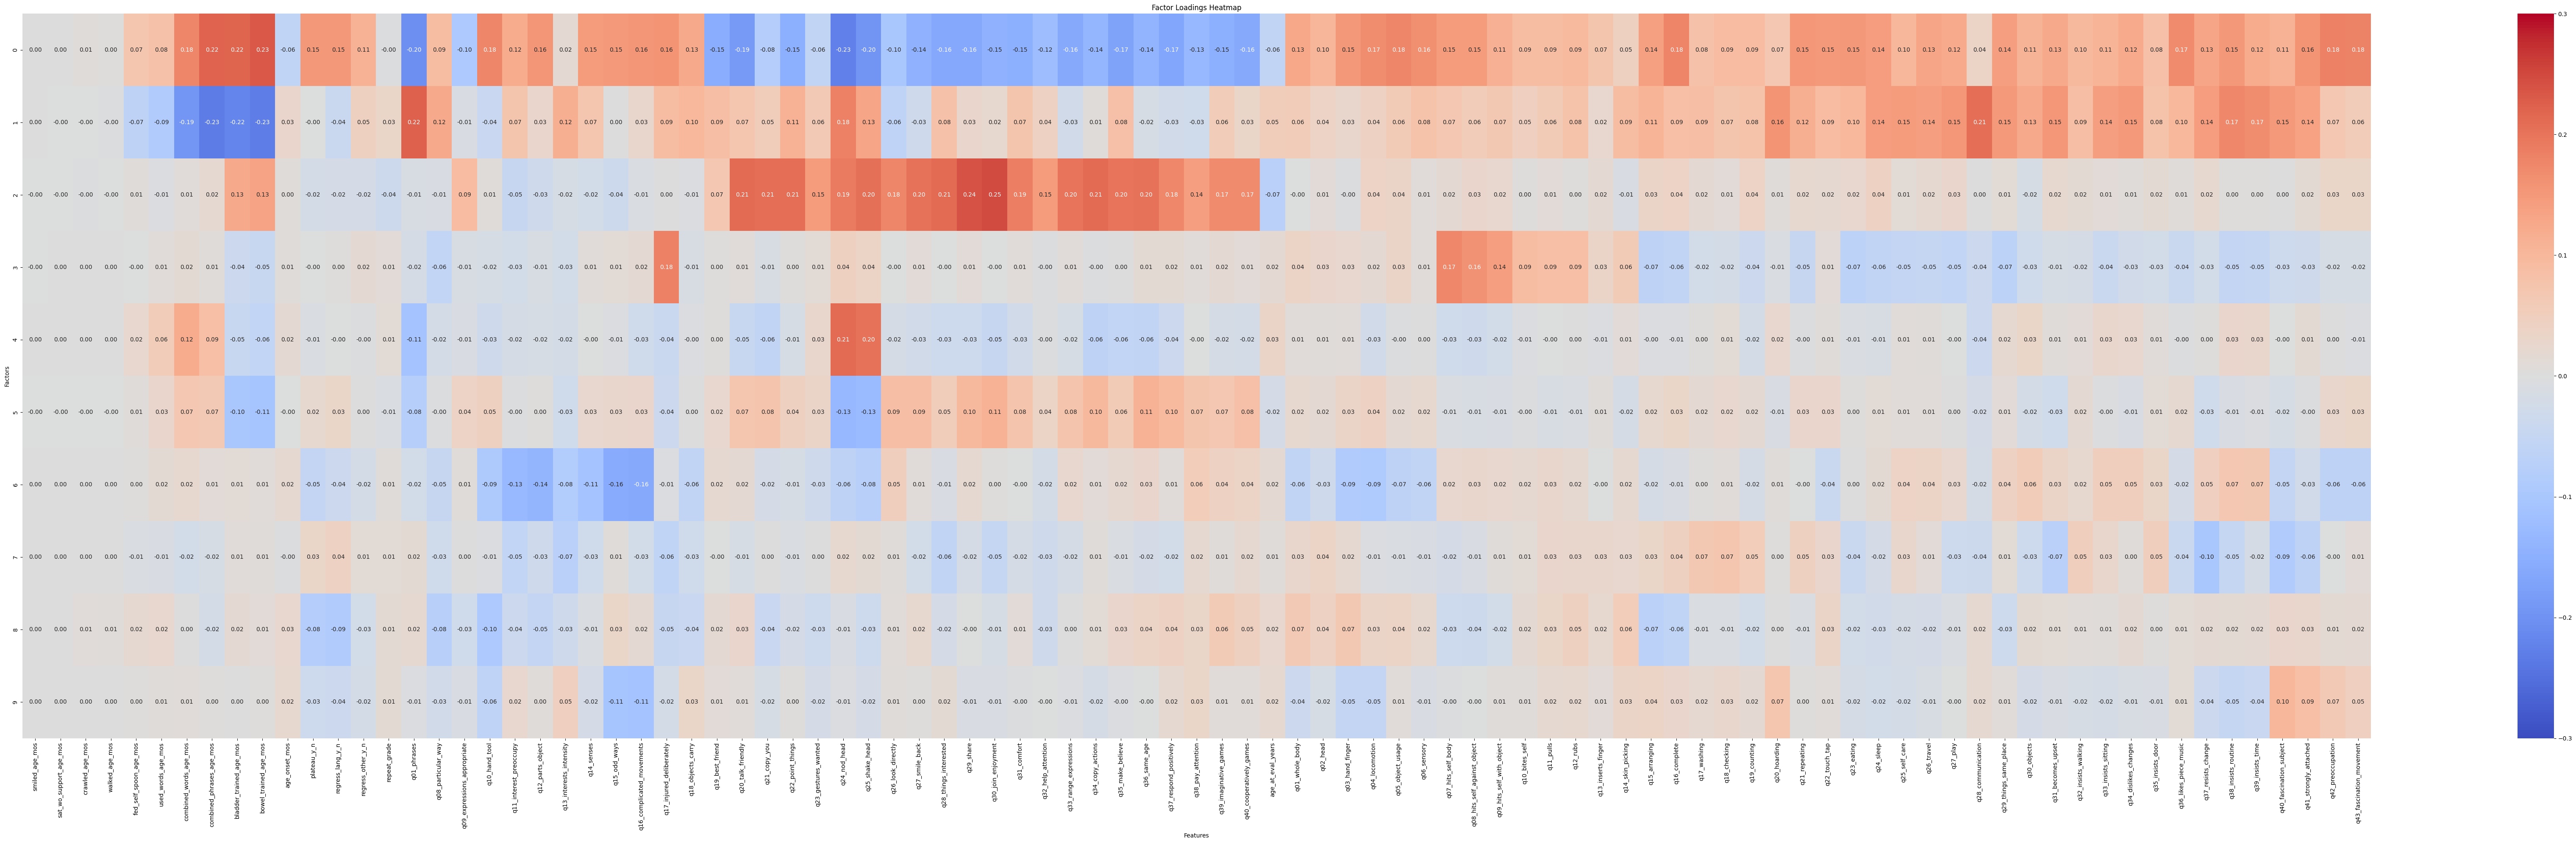

In [8]:
plt.figure(figsize=(70, 20))
sns.heatmap(factor_loadings_df, cmap="coolwarm", annot=True, fmt='.2f', vmin=-.3, vmax=.3)
plt.title('Factor Loadings Heatmap')
plt.xlabel('Features')
plt.ylabel('Factors')
plt.tight_layout()
plt.savefig("FA_Heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

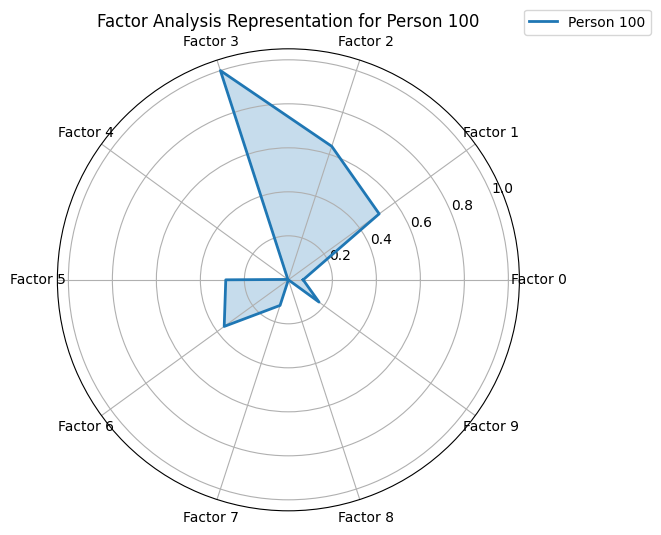

In [9]:
person_index = 99  # Change this to analyze another person
person_factors = X_train_reduced[person_index]

# Normalize the factor scores for visualization
person_factors = (person_factors - np.min(person_factors)) / (np.max(person_factors) - np.min(person_factors))

# Define angles for the radar chart (one per factor)
angles = np.linspace(0, 2 * np.pi, n_factors, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# Close the loop for plotting
values = np.append(person_factors, person_factors[0])  # Repeat first value

# Create radar plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plot the factor scores
ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Person {person_index+1}")
ax.fill(angles, values, alpha=0.25)  # Fill area

# Add labels & styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"Factor {i}" for i in range(n_factors)])
ax.set_title(f"Factor Analysis Representation for Person {person_index+1}")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

C:\Users\B00804975\.conda\envs\tf_test\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Silhouette Score: 0.12


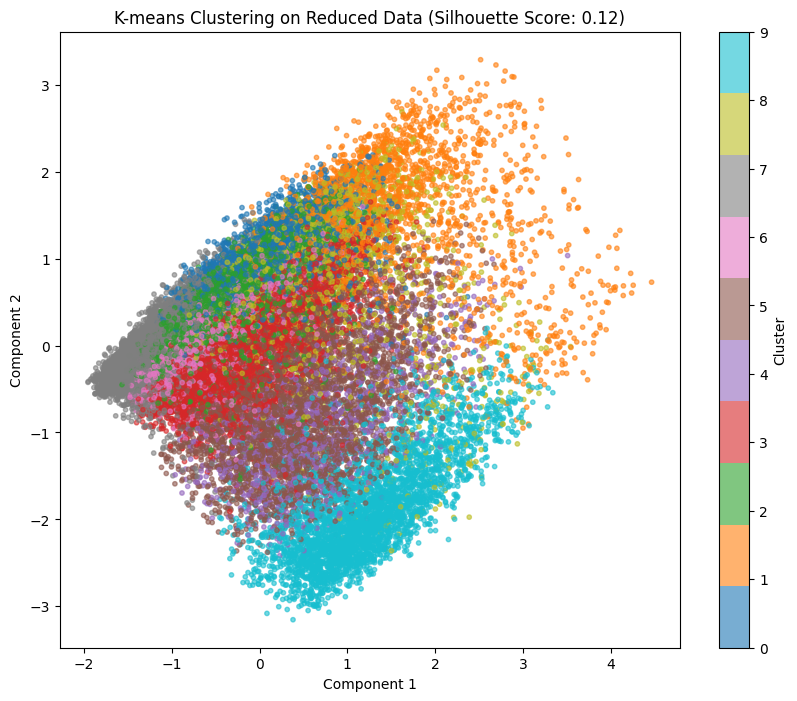

In [10]:
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_reduced = fa.fit_transform(X_scaled)
# Step 4: Apply K-means clustering to the reduced data
n_clusters = n_factors  # You can experiment with different numbers of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_reduced)

# Step 5: Calculate Silhouette Score (a measure of how well clusters are formed)
sil_score = silhouette_score(X_reduced, kmeans.labels_)
print(f"Silhouette Score: {sil_score:.2f}")

# Step 6: Visualize the reduced data with clusters
plt.figure(figsize=(10, 8))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=kmeans.labels_, cmap=cmap, alpha=0.6, s=10)
plt.title(f"K-means Clustering on Reduced Data (Silhouette Score: {sil_score:.2f})")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [11]:
n_factors_plot = 20
n_factors_range = range(1, n_factors_plot + 1)  # 1 to 20
runs_per_factor = 10  # Repeat each run 10 times

avg_log_likelihoods = []

for n in n_factors_range:
    run_scores = []
    for _ in range(runs_per_factor):
        fa = FactorAnalysis(n_components=n, random_state=None)  # No fixed seed to vary results
        fa.fit(X_scaled)
        run_scores.append(fa.score(X_scaled))  # Log-likelihood
    avg_log_likelihoods.append(np.mean(run_scores))

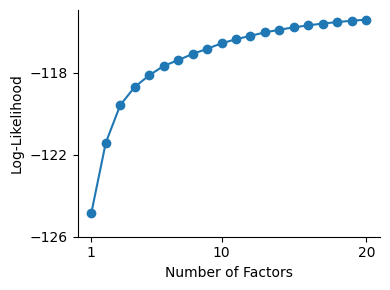

In [12]:
# Plot Log-Likelihood vs Number of Factors
plt.figure(figsize=(4, 3))
plt.plot(n_factors_range, avg_log_likelihoods, marker='o', linestyle='-')
plt.xlabel("Number of Factors")
plt.ylabel("Log-Likelihood")
plt.xticks([1,10,20])
plt.yticks([-126,-122,-118])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save as SVG
plt.tight_layout()
plt.savefig("FA_Elbow_plot.svg", format="svg", dpi=300)
plt.show()

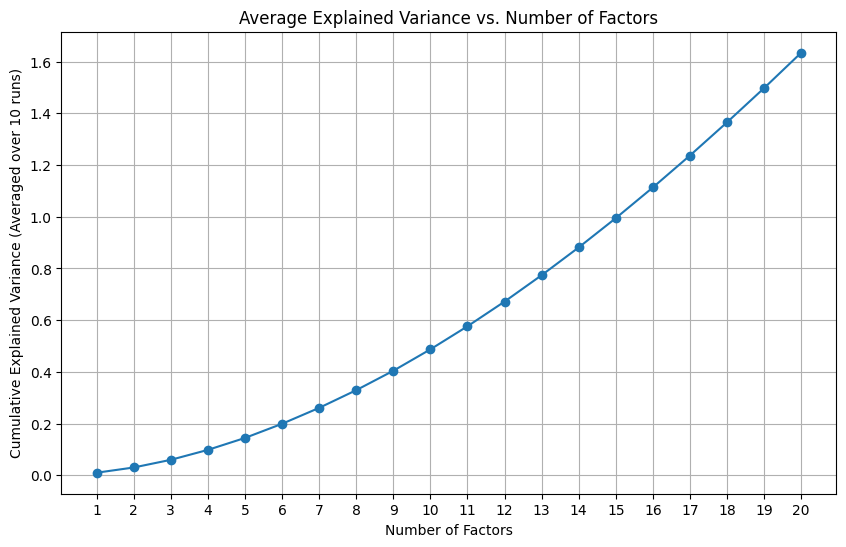

In [13]:
n_factors_plot = 20
n_runs = 10  # how many times to repeat for each factor count
avg_explained_variances = []

for n in range(1, n_factors_plot + 1):
    run_explained_variances = []
    for _ in range(n_runs):
        fa = FactorAnalysis(n_components=n, random_state=None)  # random_state=None for variability
        X_reduced = fa.fit_transform(X_scaled)
        ev = np.var(X_reduced, axis=0) / np.sum(np.var(X_scaled, axis=0))
        run_explained_variances.append(np.sum(ev))  # store total variance explained for this run
    
    avg_explained_variances.append(np.mean(run_explained_variances))  # average over runs

# Plot average cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_factors_plot + 1), np.cumsum(avg_explained_variances), marker='o', linestyle='-')
plt.xlabel("Number of Factors")
plt.ylabel("Cumulative Explained Variance (Averaged over 10 runs)")
plt.title("Average Explained Variance vs. Number of Factors")
plt.xticks(range(1, n_factors_plot + 1))
plt.grid()
plt.show()

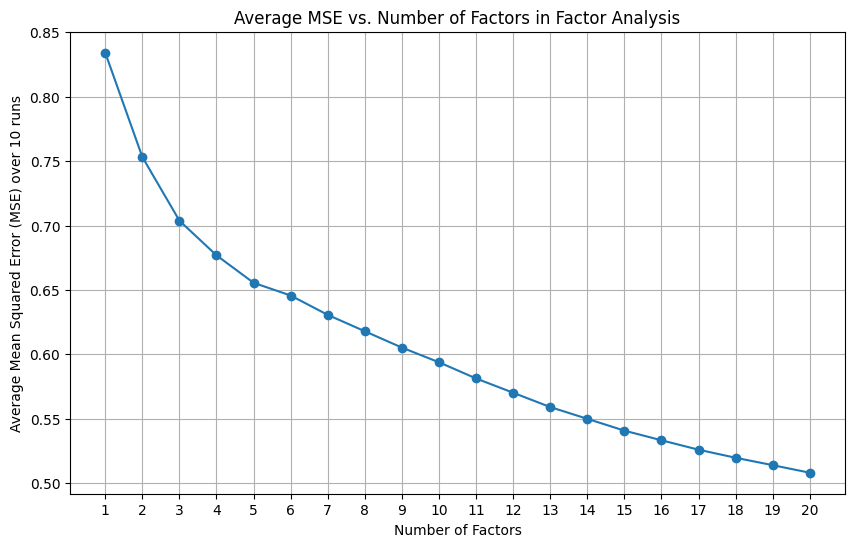

In [14]:
n_factors_plot = 20  # 1 to 20 factors
n_runs = 10  # repeat each factor count 10 times
avg_mse_scores = []

# Loop over factor counts
for n in range(1, n_factors_plot + 1):
    run_mses = []
    for _ in range(n_runs):
        fa = FactorAnalysis(n_components=n, random_state=None)  # None so runs differ
        X_reduced = fa.fit_transform(X_scaled)  # Reduce dimensions
        X_reconstructed = np.dot(X_reduced, fa.components_) + fa.mean_  # Reconstruct
        
        mse = mean_squared_error(X_scaled, X_reconstructed)
        run_mses.append(mse)
    
    avg_mse_scores.append(np.mean(run_mses))  # average over runs

# Plot average MSE vs. Number of Factors
plt.figure(figsize=(10, 6))
plt.plot((range(1, n_factors_plot + 1)), avg_mse_scores, marker='o', linestyle='-')
plt.xlabel("Number of Factors")
plt.ylabel("Average Mean Squared Error (MSE) over 10 runs")
plt.title("Average MSE vs. Number of Factors in Factor Analysis")
plt.xticks(range(1, n_factors_plot + 1))
plt.grid()
plt.show()

In [15]:
from sklearn.model_selection import KFold

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_train)

# Parameters
n_splits = 5         # number of CV folds
n_factors = 10       # number of factors for FA

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
mse_scores = []

# K-Fold CV loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    X_train_cv, X_val_cv = X_scaled[train_idx], X_scaled[val_idx]
    
    # Apply Factor Analysis
    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    X_train_fa = fa.fit_transform(X_train_cv)
    X_val_fa = fa.transform(X_val_cv)
    
    # Reconstruct validation data from reduced factors
    X_val_reconstructed = np.dot(X_val_fa, fa.components_) + fa.mean_
    
    # Calculate Mean Squared Error
    mse = mean_squared_error(X_val_cv, X_val_reconstructed)
    mse_scores.append(mse)
    
    print(f"Fold {fold + 1}: MSE = {mse:.4f}")

# Average MSE across all folds
mean_mse = np.mean(mse_scores)
print(f"\nAverage Reconstruction MSE (CV): {mean_mse:.4f}")

Fold 1: MSE = 0.6047
Fold 2: MSE = 0.5993
Fold 3: MSE = 0.5906
Fold 4: MSE = 0.5779
Fold 5: MSE = 0.5922

Average Reconstruction MSE (CV): 0.5929


In [16]:
X_train = df.values  # Full dataset (excluding classification column)

# Apply Factor Analysis
fa = FactorAnalysis(n_components=10, random_state=42)
X_train_reduced = fa.fit_transform(X_train)

In [17]:
n_splits = 30
input_dim = df.shape[1]

val_losses = []

for i in range(n_splits):
    print(f"Split {i+1}/{n_splits}")
    
    # Make a new train/val split
    train_data, val_data = train_test_split(df, test_size=0.2, random_state=None)
    
    fa = FactorAnalysis(n_components=10, random_state=42)
    X_train_reduced = fa.fit_transform(train_data)
    X_test_reduced = fa.transform(val_data)

    factor_loadings = fa.components_
    factor_loadings_df = pd.DataFrame(factor_loadings, columns=df.columns)
    
    
    # Record the final val loss
    val_losses.append(fa.score(train_data))

Split 1/30
Split 2/30
Split 3/30
Split 4/30
Split 5/30
Split 6/30
Split 7/30
Split 8/30
Split 9/30
Split 10/30
Split 11/30
Split 12/30
Split 13/30
Split 14/30
Split 15/30
Split 16/30
Split 17/30
Split 18/30
Split 19/30
Split 20/30
Split 21/30
Split 22/30
Split 23/30
Split 24/30
Split 25/30
Split 26/30
Split 27/30
Split 28/30
Split 29/30
Split 30/30


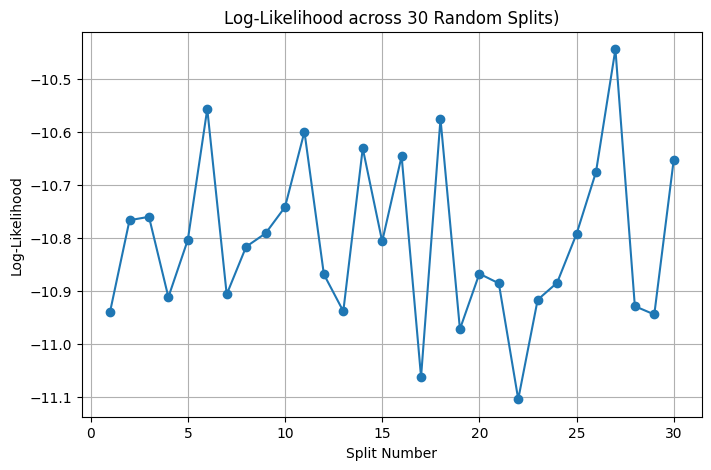

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_splits+1), val_losses, marker='o')
plt.title(f"Log-Likelihood across {n_splits} Random Splits)")
plt.xlabel("Split Number")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()

In [19]:
from sklearn.metrics import mean_squared_error
# Reduce the data
X_reduced = fa.transform(X_scaled)  

# Reconstruct the data
X_reconstructed = np.dot(X_reduced, fa.components_) + fa.mean_

# Compute reconstruction error (MSE) for entire dataset
mse = mean_squared_error(X_scaled, X_reconstructed)
print(f"Mean Reconstruction Error (MSE): {mse:.4f}")

Mean Reconstruction Error (MSE): 0.6641


C:\Users\B00804975\.conda\envs\tf_test\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but FactorAnalysis was fitted with feature names
  warnings.warn(


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

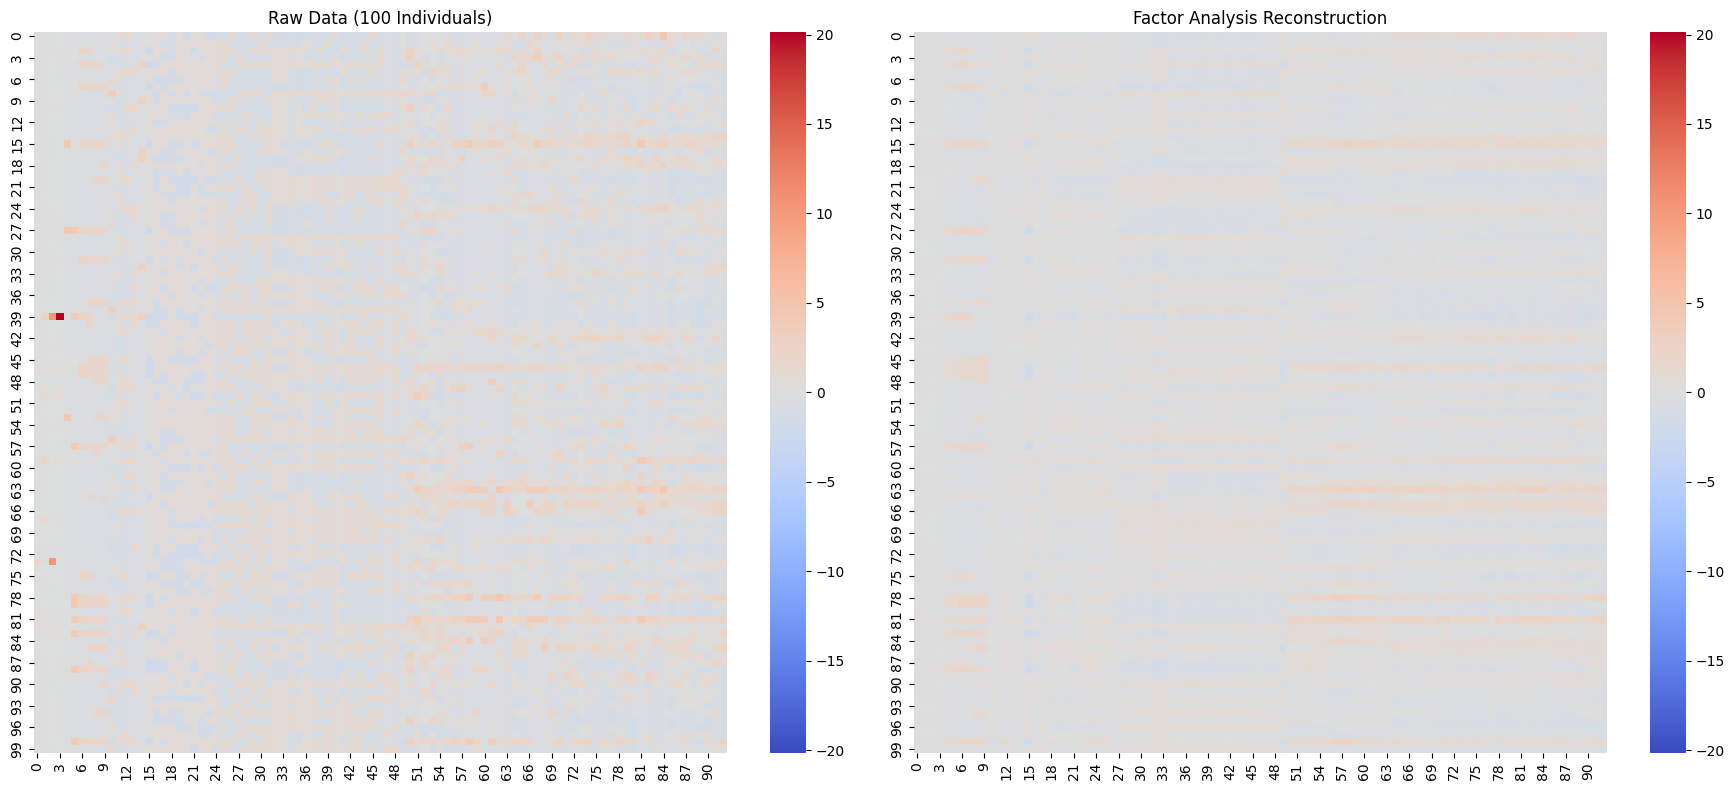

In [21]:
np.random.seed(42)

# Same 100 individuals everywhere
idx = np.random.choice(X_scaled.shape[0], size=100, replace=False)
X_raw_100 = X_scaled[idx]

raw_df = pd.DataFrame(X_raw_100)
raw_df.columns = range(raw_df.shape[1])
fa = FactorAnalysis(n_components=10, random_state=42)

# Fit on FULL dataset
X_latent = fa.fit_transform(X_scaled)
X_reconstructed = X_latent @ fa.components_ + fa.mean_

X_recon_fa = X_reconstructed[idx]

raw_df = pd.DataFrame(X_raw_100)
recon_df = pd.DataFrame(X_recon_fa)

raw_df.columns = recon_df.columns = range(raw_df.shape[1])


abs_max = np.abs(X_raw_100).max()

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
sns.heatmap(raw_df, cmap="coolwarm",vmin=-abs_max, vmax=abs_max)
plt.title("Raw Data (100 Individuals)")

plt.subplot(1, 2, 2)
sns.heatmap(recon_df, cmap="coolwarm", vmin=-abs_max, vmax=abs_max)
plt.title("Factor Analysis Reconstruction")

plt.savefig("FA_Recon_data.svg", format="svg", dpi=300)
plt.tight_layout()
plt.show()

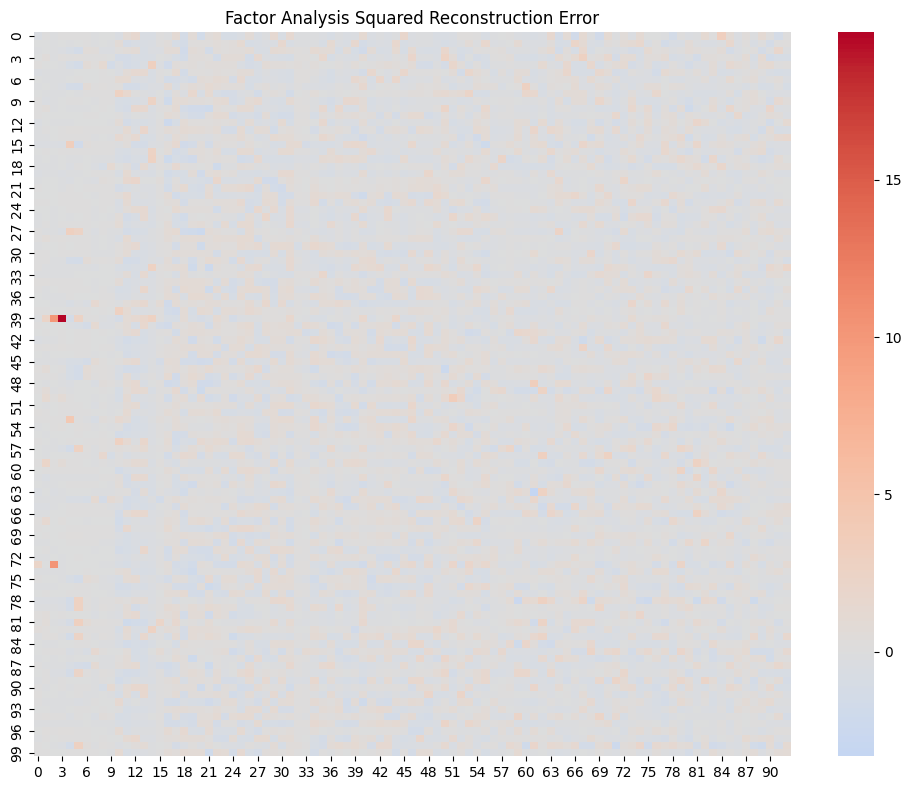

In [22]:
err_df = pd.DataFrame((X_raw_100 - X_recon_fa))
vmax = np.percentile(err_df.values, 99)

plt.figure(figsize=(10, 8))
sns.heatmap(err_df, cmap="coolwarm", center = 0)
plt.title("Factor Analysis Squared Reconstruction Error")

plt.tight_layout()
plt.savefig("FA_Squared_Error.svg", dpi=300)
plt.show()

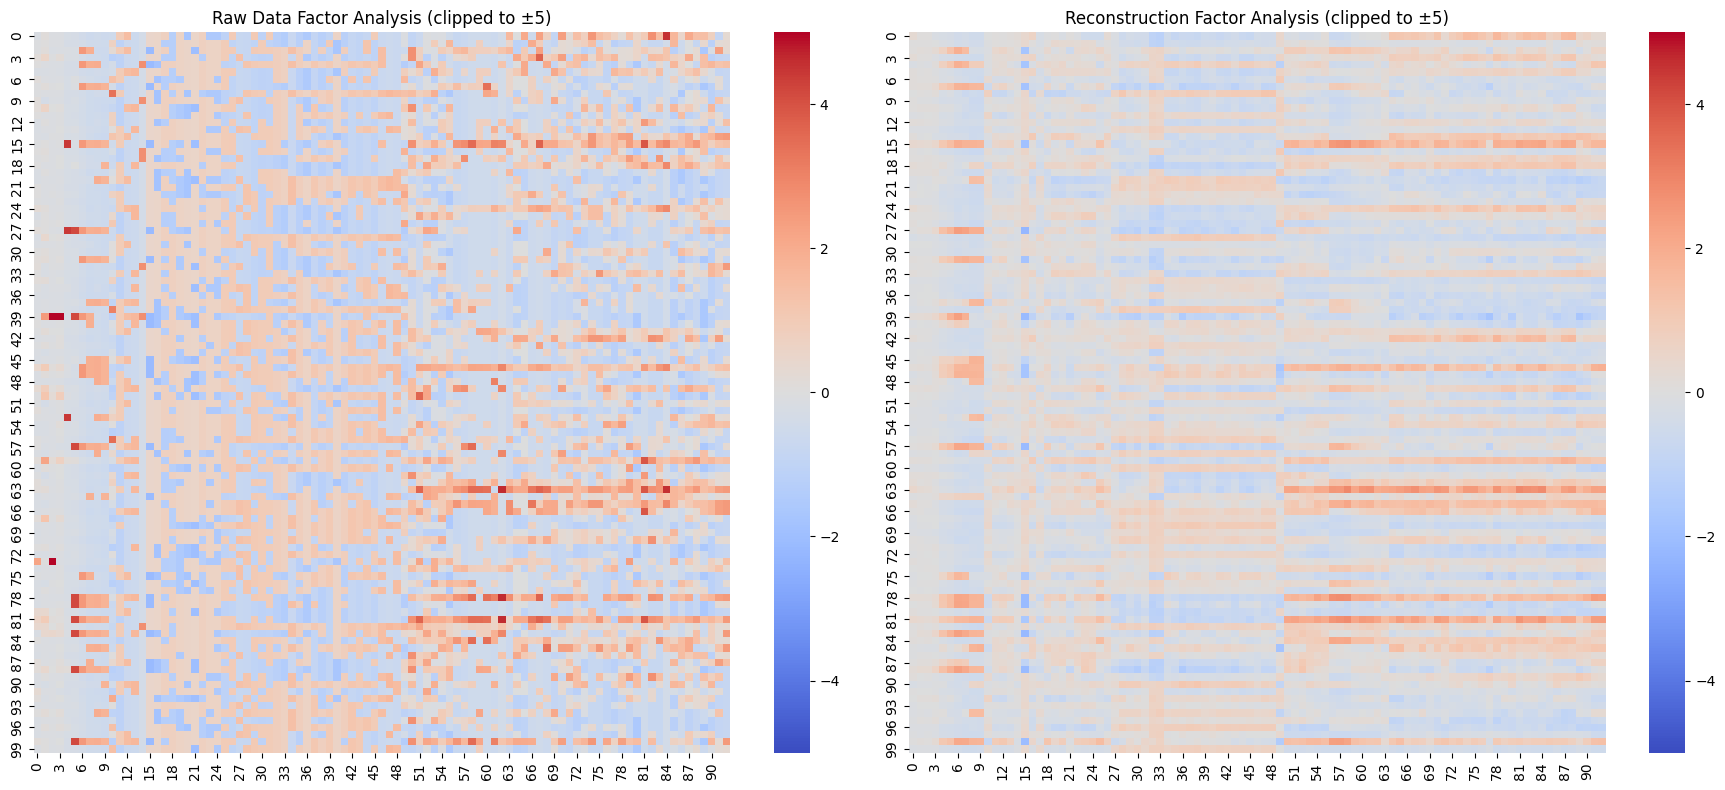

In [23]:
abs_max = np.abs(X_raw_100).max()
abs_max = 5
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
sns.heatmap(
    raw_df,
    cmap="coolwarm",
    vmin=-5,
    vmax=5
)
plt.title("Raw Data Factor Analysis (clipped to ±5)")

plt.subplot(1, 2, 2)
sns.heatmap(
    recon_df,
    cmap="coolwarm",
    vmin=-5,
    vmax=5
)
plt.title("Reconstruction Factor Analysis (clipped to ±5)")

plt.savefig("FA_Recon_data(+-5).svg", format="svg", dpi=300)
plt.tight_layout()
plt.show()
